# Singular Spectrum Analysis (SSA)

This notebook introduces **Singular Spectrum Analysis (SSA)** — a nonparametric
method for decomposing a univariate time series into interpretable additive
components (trend, oscillations, and noise) via embedding and singular-value
decomposition.

Unlike EMD / VMD, SSA does **not** rely on iterative sifting or a variational
bandwidth prior.  It works entirely in a linear-algebra framework:

1. embed the series into a trajectory (Hankel) matrix;
2. compute an eigendecomposition / SVD of that matrix;
3. group the leading singular components;
4. diagonal-average each group back to a 1-D series.

**Reference**

> Zhigljavsky, A. A.  
> *Singular spectrum analysis for time series: Introduction to this special issue.*  
> Statistics and its Interface, 3(3):255–258, 2010.

MATLAB beginners’ guide:  
https://www.mathworks.com/matlabcentral/fileexchange/58967-singular-spectrum-analysis-beginners-guide

## 1. Imports

In [ ]:
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if not (ROOT / "pysdkit").is_dir():
    for parent in ROOT.parents:
        if (parent / "pysdkit").is_dir():
            ROOT = parent
            break
if str(ROOT) not in sys.path and (ROOT / "pysdkit").is_dir():
    sys.path.insert(0, str(ROOT))

import numpy as np
import matplotlib.pyplot as plt

from pysdkit import SSA
from pysdkit.data import test_emd
from pysdkit.plot import plot_IMFs, plot_IMFs_amplitude_spectra

print(SSA())


Singular Spectral Analysis (SSA)


## 2. Algorithm principles

### 2.1 Embedding — trajectory matrix

Given a series $x = (x_1,\ldots,x_N)$ and a window length (embedding
dimension) $L$ with $2 \le L \le N/2$, SSA builds the **trajectory matrix**

$$
X =
\begin{bmatrix}
x_1 & x_2 & \cdots & x_K \\
x_2 & x_3 & \cdots & x_{K+1} \\
\vdots & \vdots & \ddots & \vdots \\
x_L & x_{L+1} & \cdots & x_N
\end{bmatrix}
\in \mathbb{R}^{L \times K},
\qquad K = N - L + 1.
$$

$X$ is a **Hankel matrix**: entries on anti-diagonals $i+j$ are constant.
In `PySDKit` this embedding is obtained with `mode="traj"` (the default).

### 2.2 Decomposition — SVD / eigendecomposition

Compute the SVD

$$
X = U\,\Sigma\,V^{\mathsf T}
= \sum_{i=1}^{d} \sigma_i\, u_i v_i^{\mathsf T},
$$

where $\sigma_1 \ge \sigma_2 \ge \cdots \ge \sigma_d > 0$ are singular values.
Equivalently, the eigenvectors of the lag-covariance $R = X^{\mathsf T}X$
are the right singular vectors $v_i$, with $\sigma_i = \sqrt{\lambda_i(R)}$.

Each **elementary matrix**

$$
X_i = \sigma_i\, u_i v_i^{\mathsf T} = (X v_i)\, v_i^{\mathsf T}
$$

captures one orthogonal contribution to the embedded signal.  The parameter
`K` in `SSA(K=...)` keeps the $K$ largest such components (the signal
subspace).

### 2.3 Reconstruction — diagonal averaging

To map $X_i$ back to a length-$N$ series, average all entries that belong to
the same anti-diagonal (Hankelization):

$$
\tilde{x}^{(i)}_n
= \frac{1}{\#\{(p,q): p+q = n+1\}}
\sum_{p+q=n+1} (X_i)_{p,q}.
$$

The additive decomposition is then

$$
x \approx \sum_{i=1}^{K} \tilde{x}^{(i)}.
$$

Pure harmonics typically occupy a **pair** of singular components (sine /
cosine phase), while a smooth trend often lives in the leading one or two
components, and noise fills the small singular values.

## 3. Synthetic example — two tones

We first build a clean mixture of two sinusoids.  Each tone spans a
2-dimensional SSA subspace, so `K=4` is enough for an essentially exact
reconstruction.

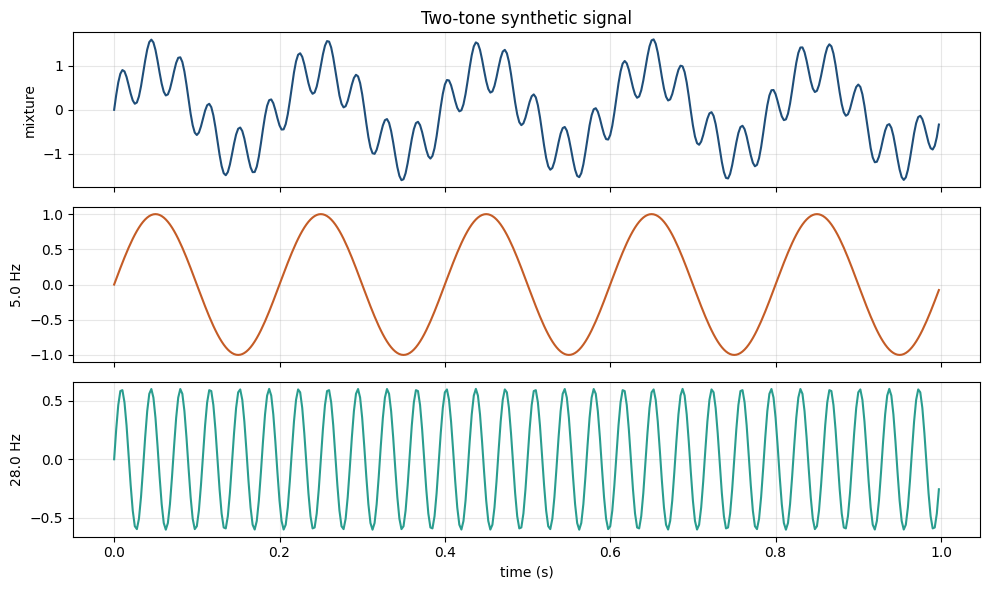

In [2]:
N = 400
fs = 400.0
t = np.arange(N) / fs

f1, f2 = 5.0, 28.0
comp1 = np.sin(2 * np.pi * f1 * t)
comp2 = 0.6 * np.sin(2 * np.pi * f2 * t)
signal = comp1 + comp2

fig, axes = plt.subplots(3, 1, figsize=(10, 6), sharex=True)
axes[0].plot(t, signal, color="#1f4e79")
axes[0].set_ylabel("mixture")
axes[0].set_title("Two-tone synthetic signal")
axes[1].plot(t, comp1, color="#c45c26")
axes[1].set_ylabel(f"{f1} Hz")
axes[2].plot(t, comp2, color="#2a9d8f")
axes[2].set_ylabel(f"{f2} Hz")
axes[2].set_xlabel("time (s)")
for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 3.1 Run SSA

PySDKit exposes the usual scikit-learn-style interface:

1. create an `SSA` instance;
2. call `fit_transform` (or call the instance directly).

In [3]:
ssa = SSA(K=4, mode="traj", lags=80)
IMFs = ssa.fit_transform(signal)

print("IMFs shape:", IMFs.shape)
rel_err = np.linalg.norm(IMFs.sum(axis=0) - signal) / np.linalg.norm(signal)
print(f"relative reconstruction error: {rel_err:.3e}")

IMFs shape: (4, 400)
relative reconstruction error: 3.460e-15


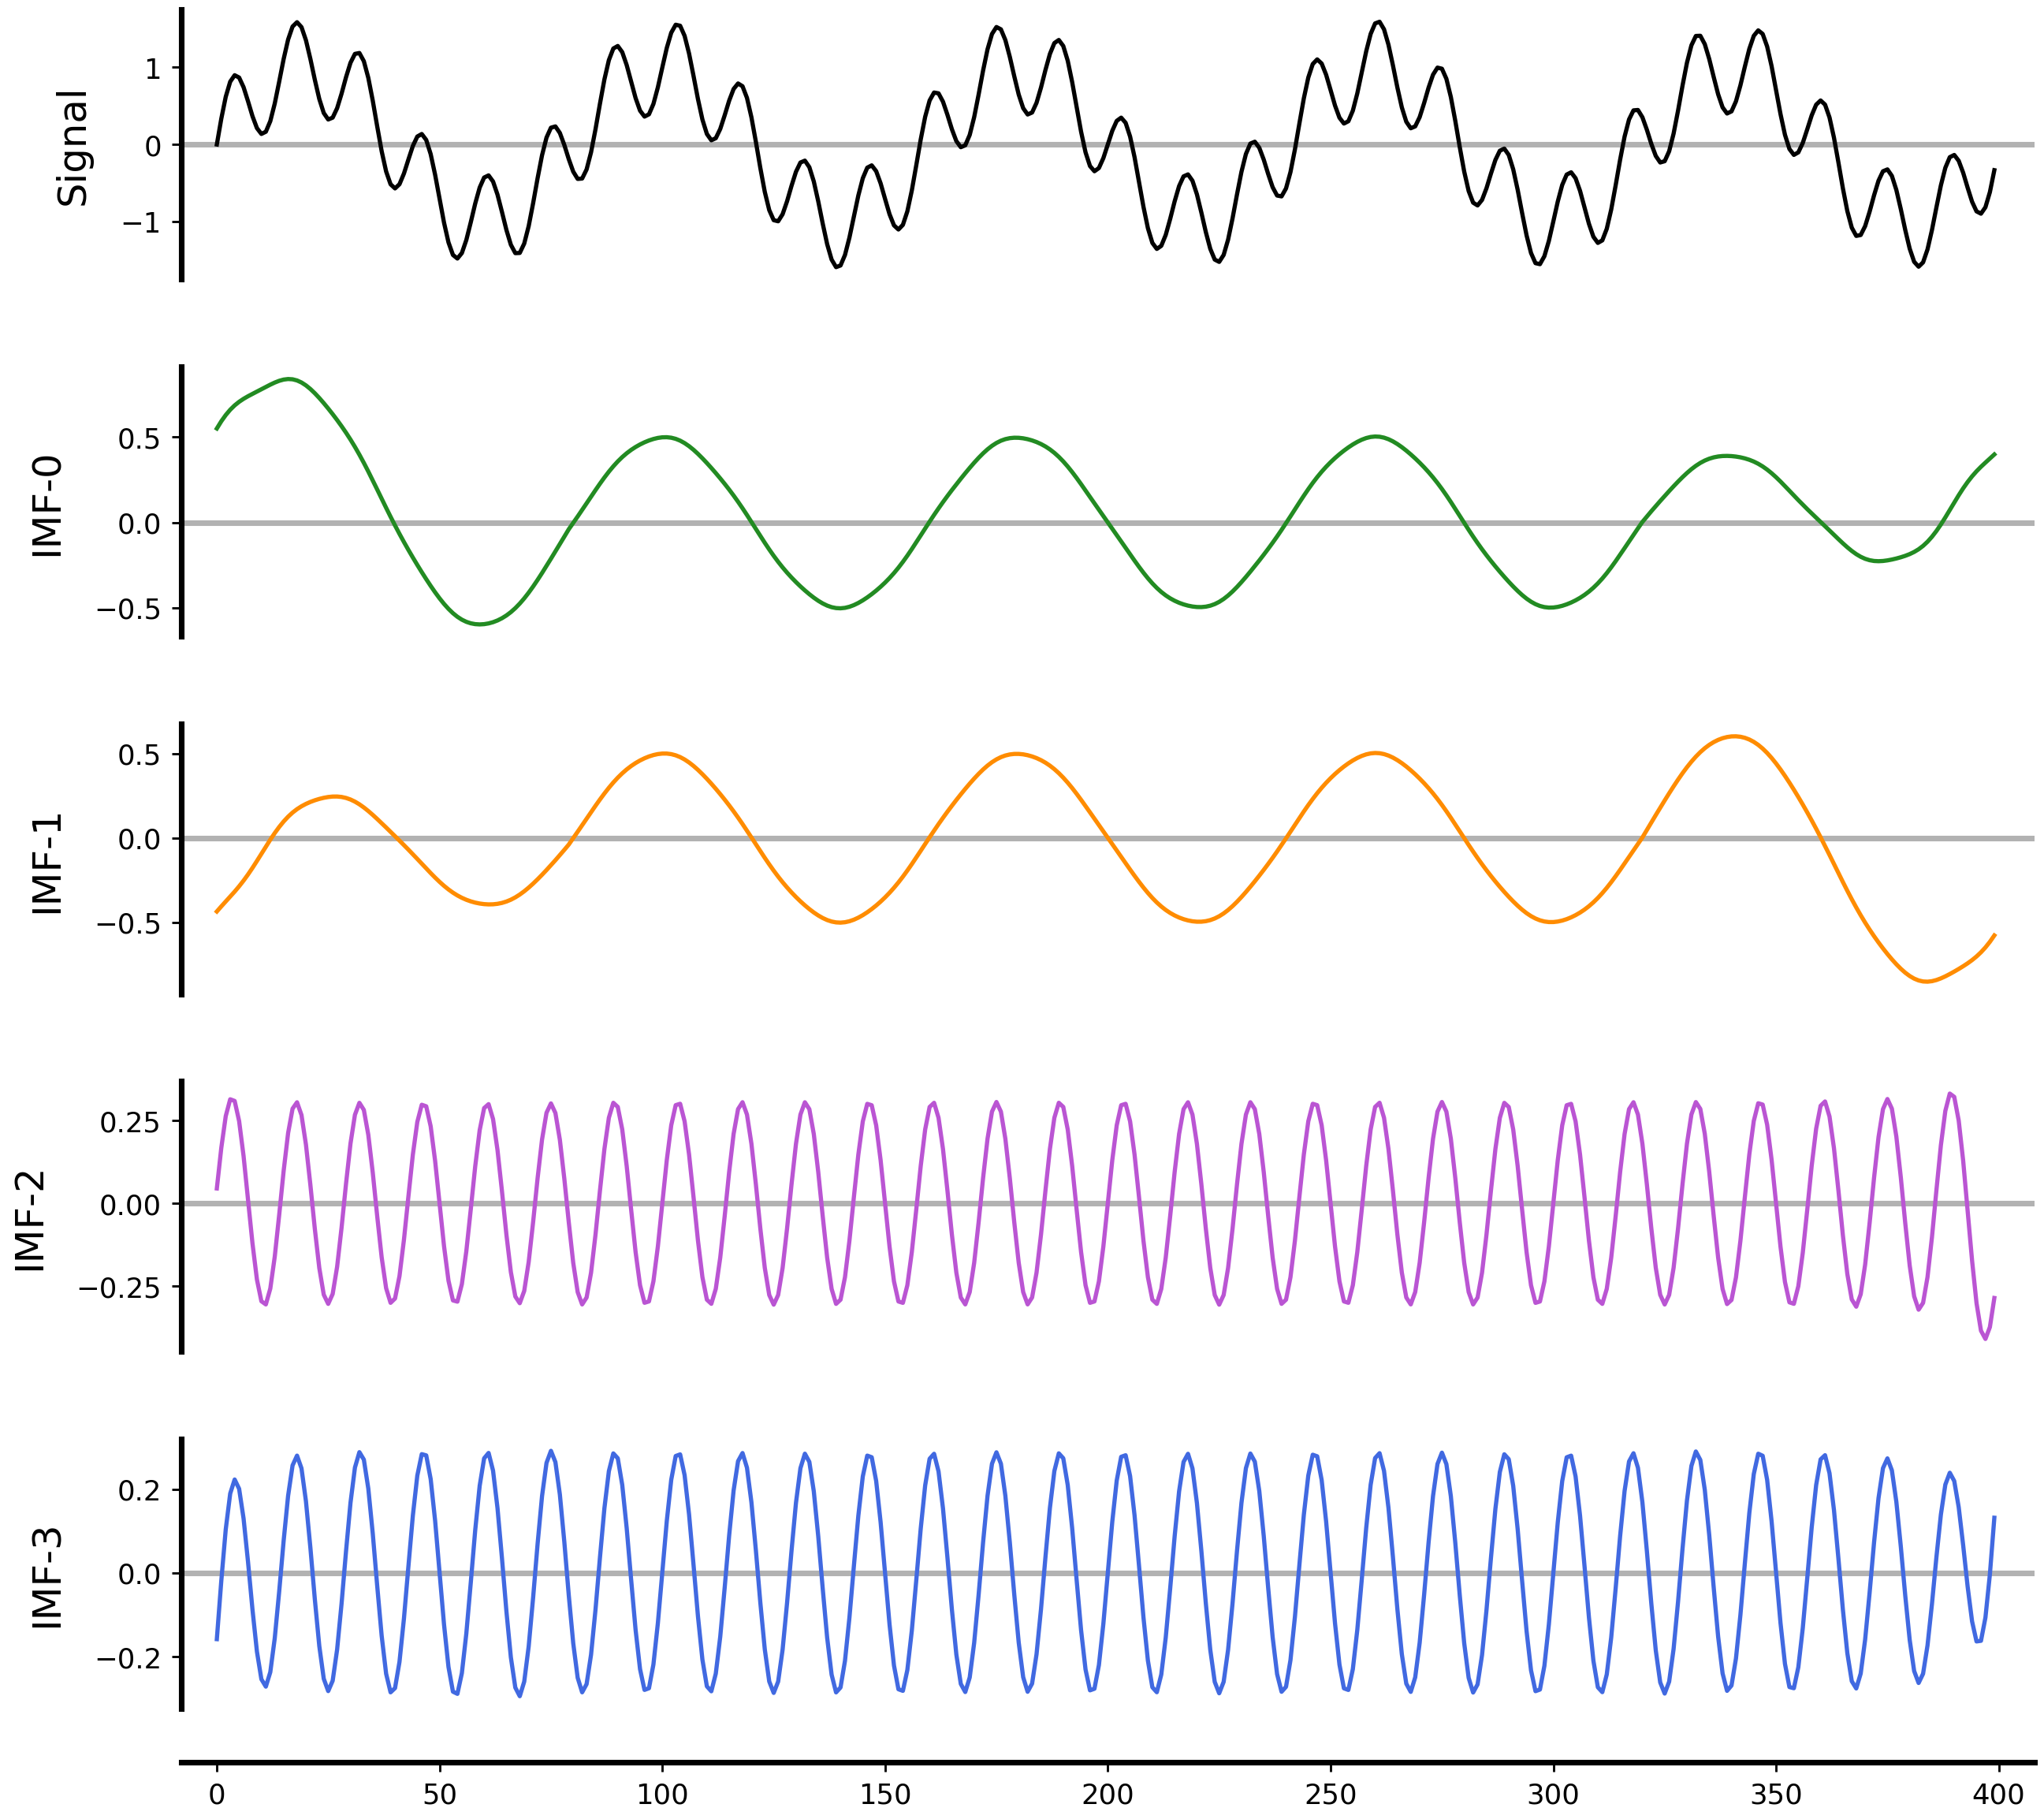

In [4]:
fig = plot_IMFs(signal, IMFs, return_figure=True)
plt.show()

### 3.2 Frequency-domain view

Amplitude spectra make the pairing of SSA components for each tone visible:
components 0–1 concentrate energy near $5\,\mathrm{Hz}$, while 2–3 sit near
$28\,\mathrm{Hz}$.

run classic


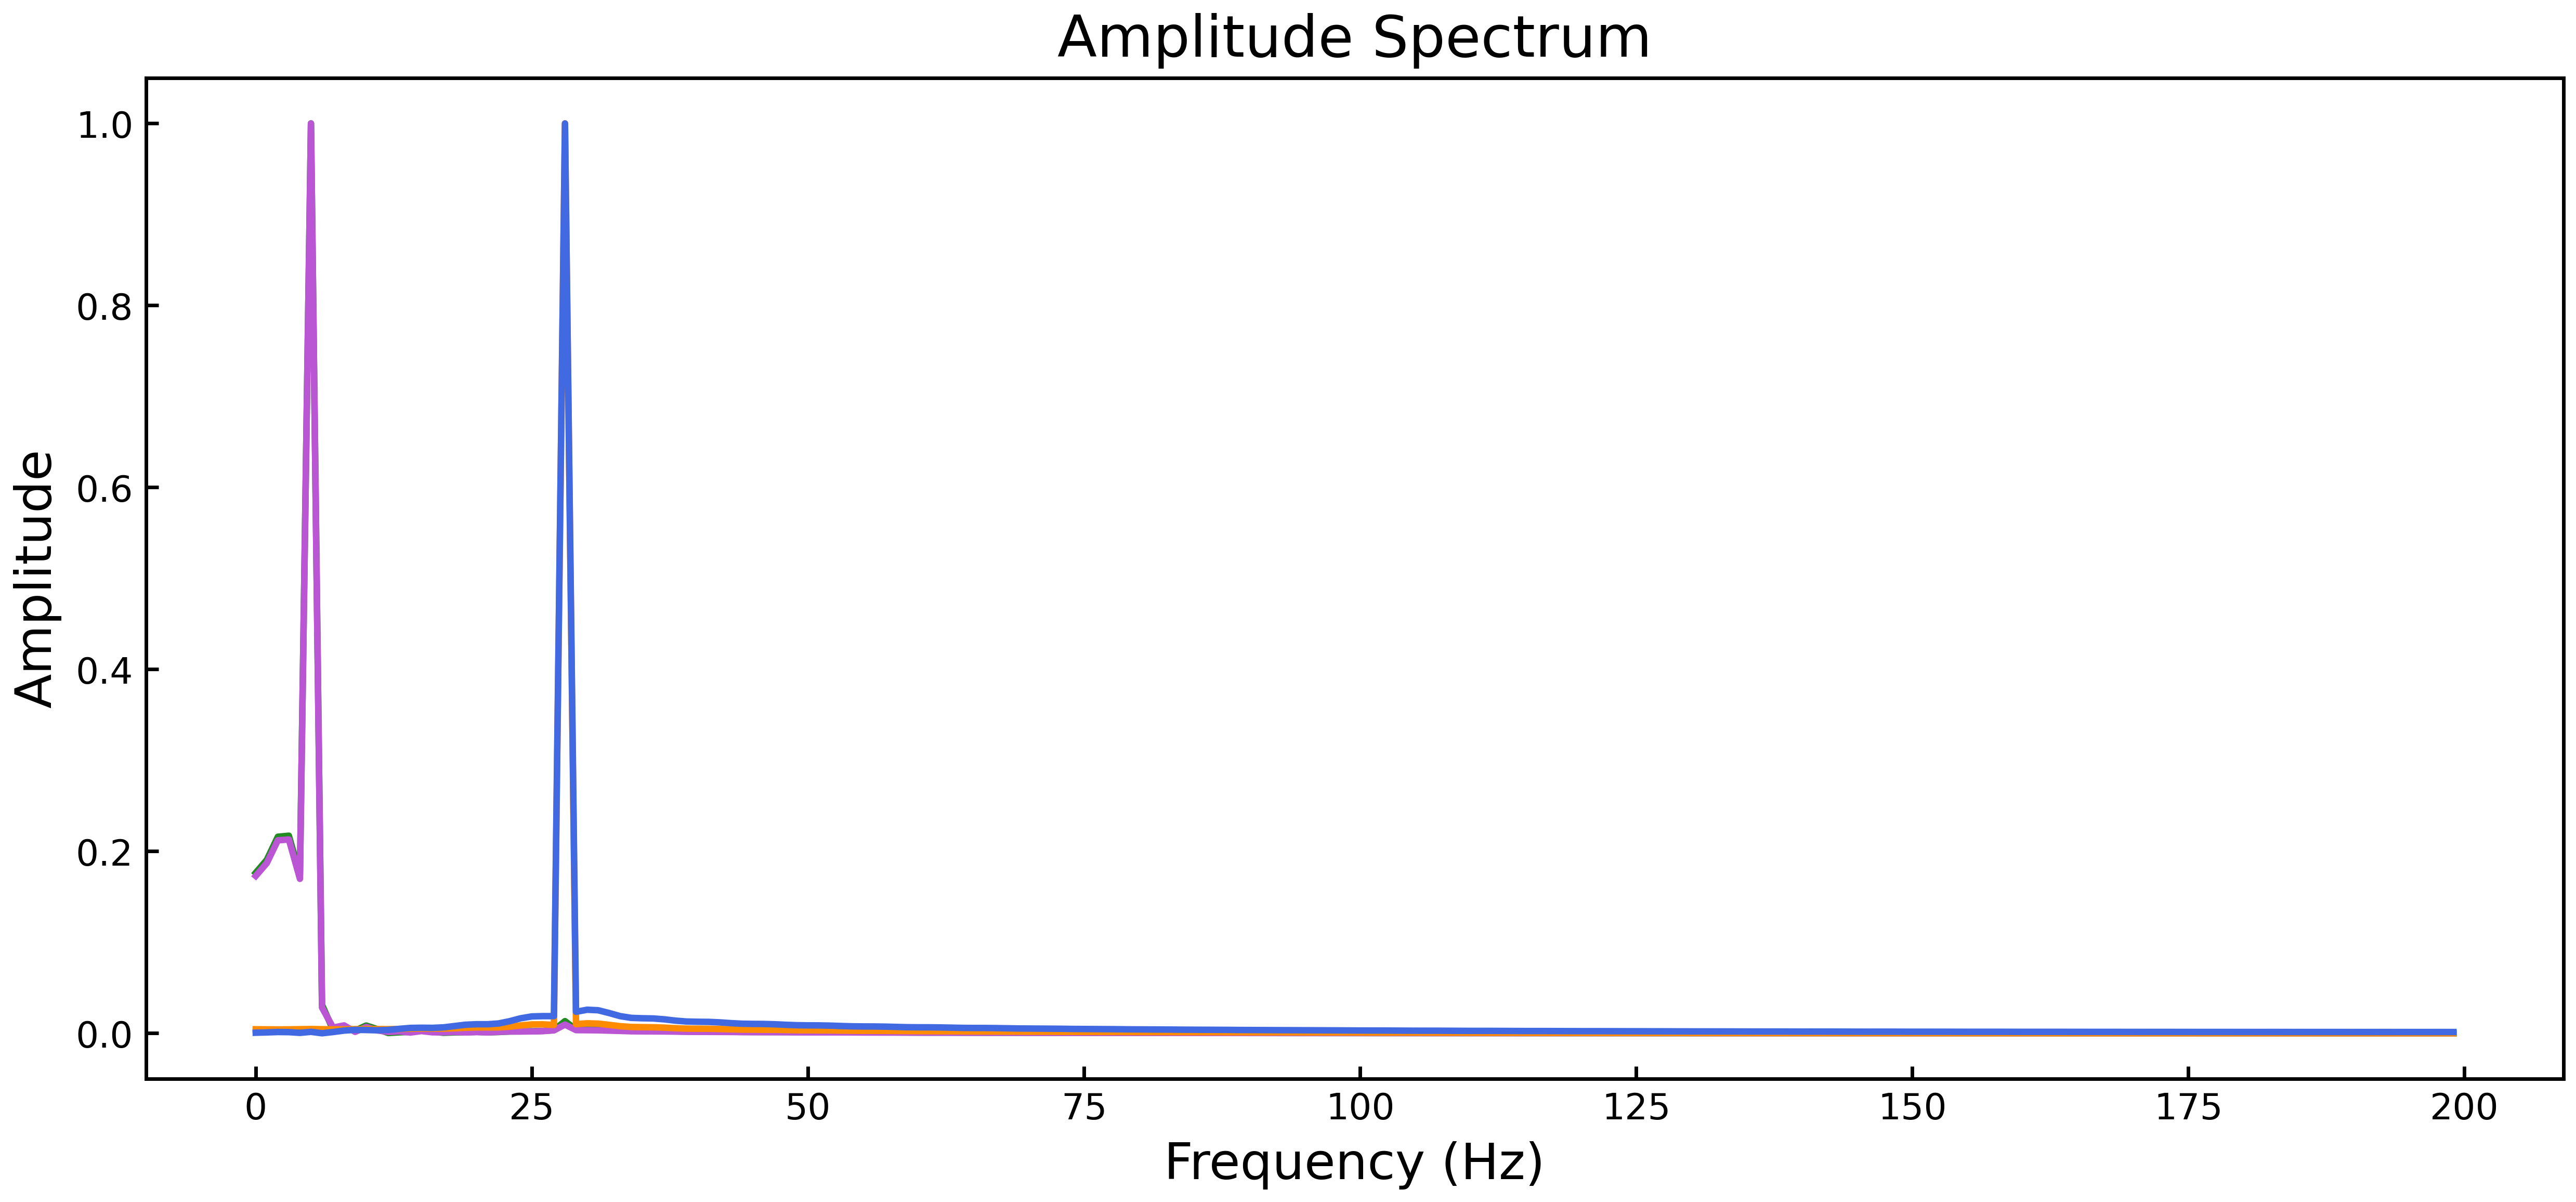

In [5]:
fig = plot_IMFs_amplitude_spectra(IMFs, return_figure=True)
plt.show()

## 4. Built-in test signal (`test_emd`)

Next we apply SSA to the library’s chirp + trend example.  With a modest
subspace size the leading components capture the slow trend and the main
oscillation; residual energy remains in the discarded singular directions.

In [6]:
time, emd_signal = test_emd()

ssa_emd = SSA(K=6, mode="traj")
IMFs_emd = ssa_emd.fit_transform(emd_signal)

print("signal length:", emd_signal.size)
print("IMFs shape:", IMFs_emd.shape)
rel_err = np.linalg.norm(IMFs_emd.sum(0) - emd_signal) / np.linalg.norm(emd_signal)
print(f"relative reconstruction error (K=6): {rel_err:.4f}")

signal length: 1000
IMFs shape: (6, 1000)
relative reconstruction error (K=6): 0.4307


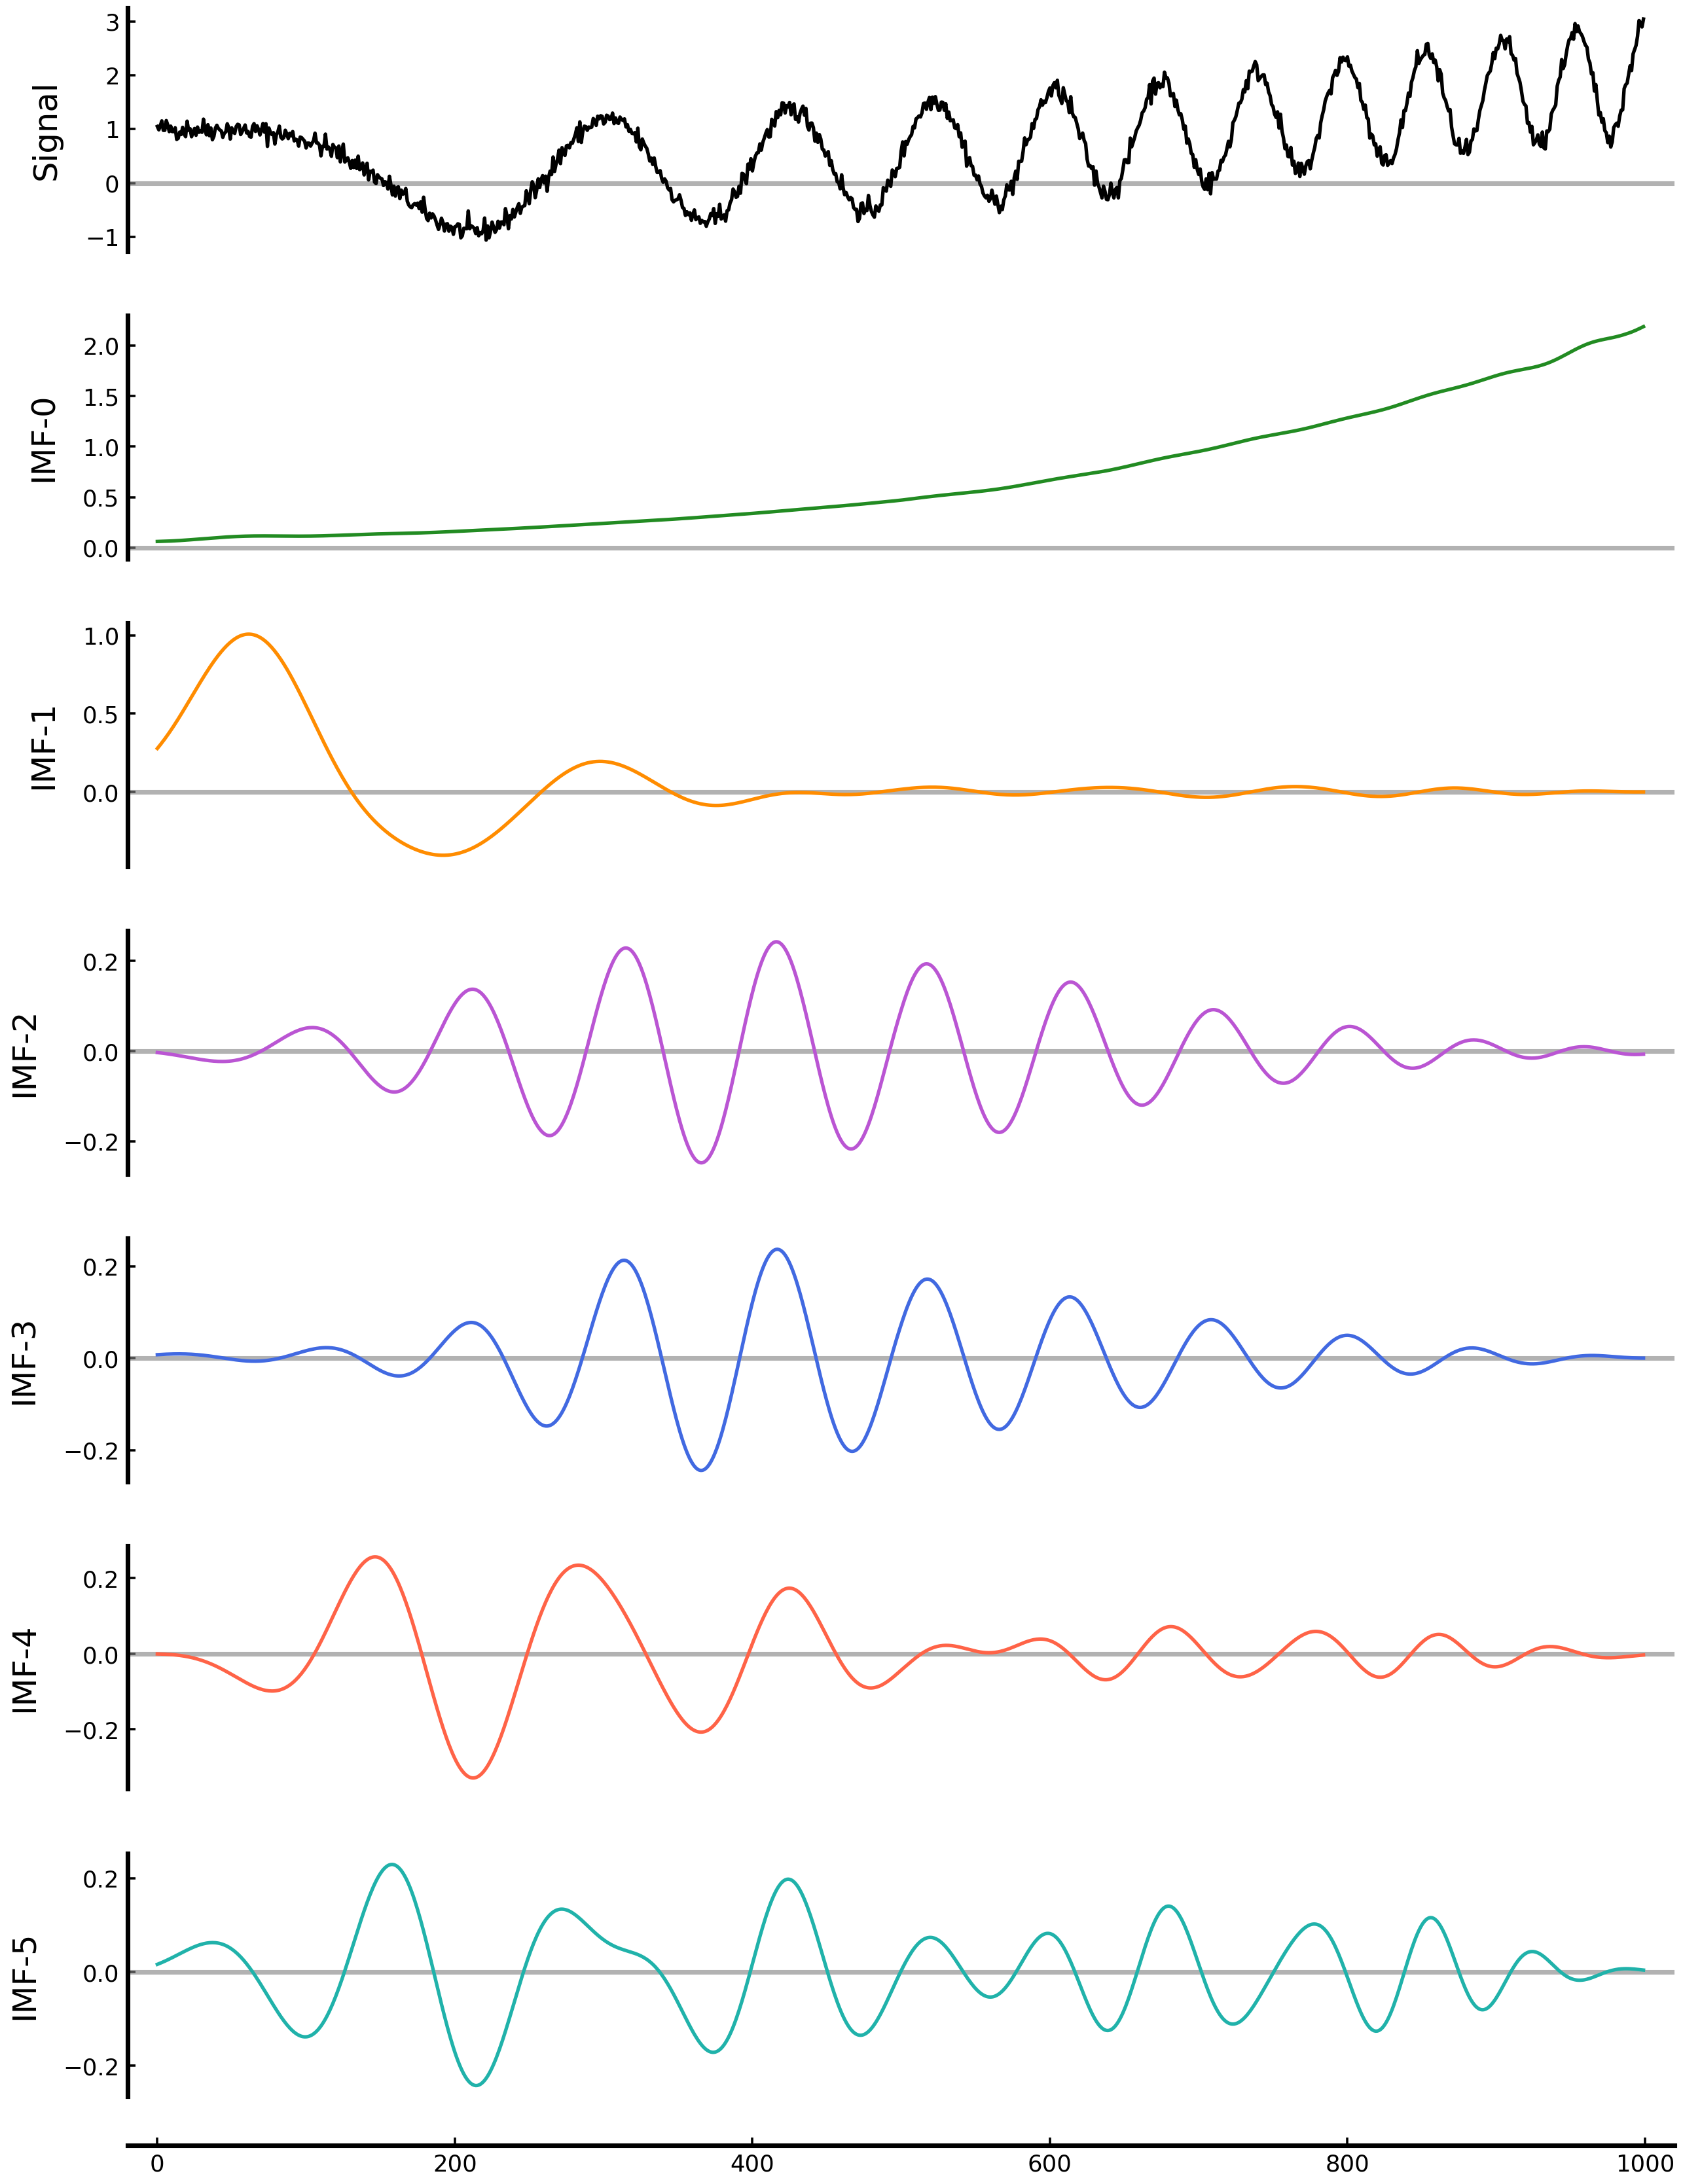

In [7]:
fig = plot_IMFs(emd_signal, IMFs_emd, return_figure=True)
plt.show()

### 4.1 Effect of the subspace size $K$

Increasing $K$ keeps more singular components and therefore reduces the
reconstruction residual — at the cost of admitting more noise-like modes.

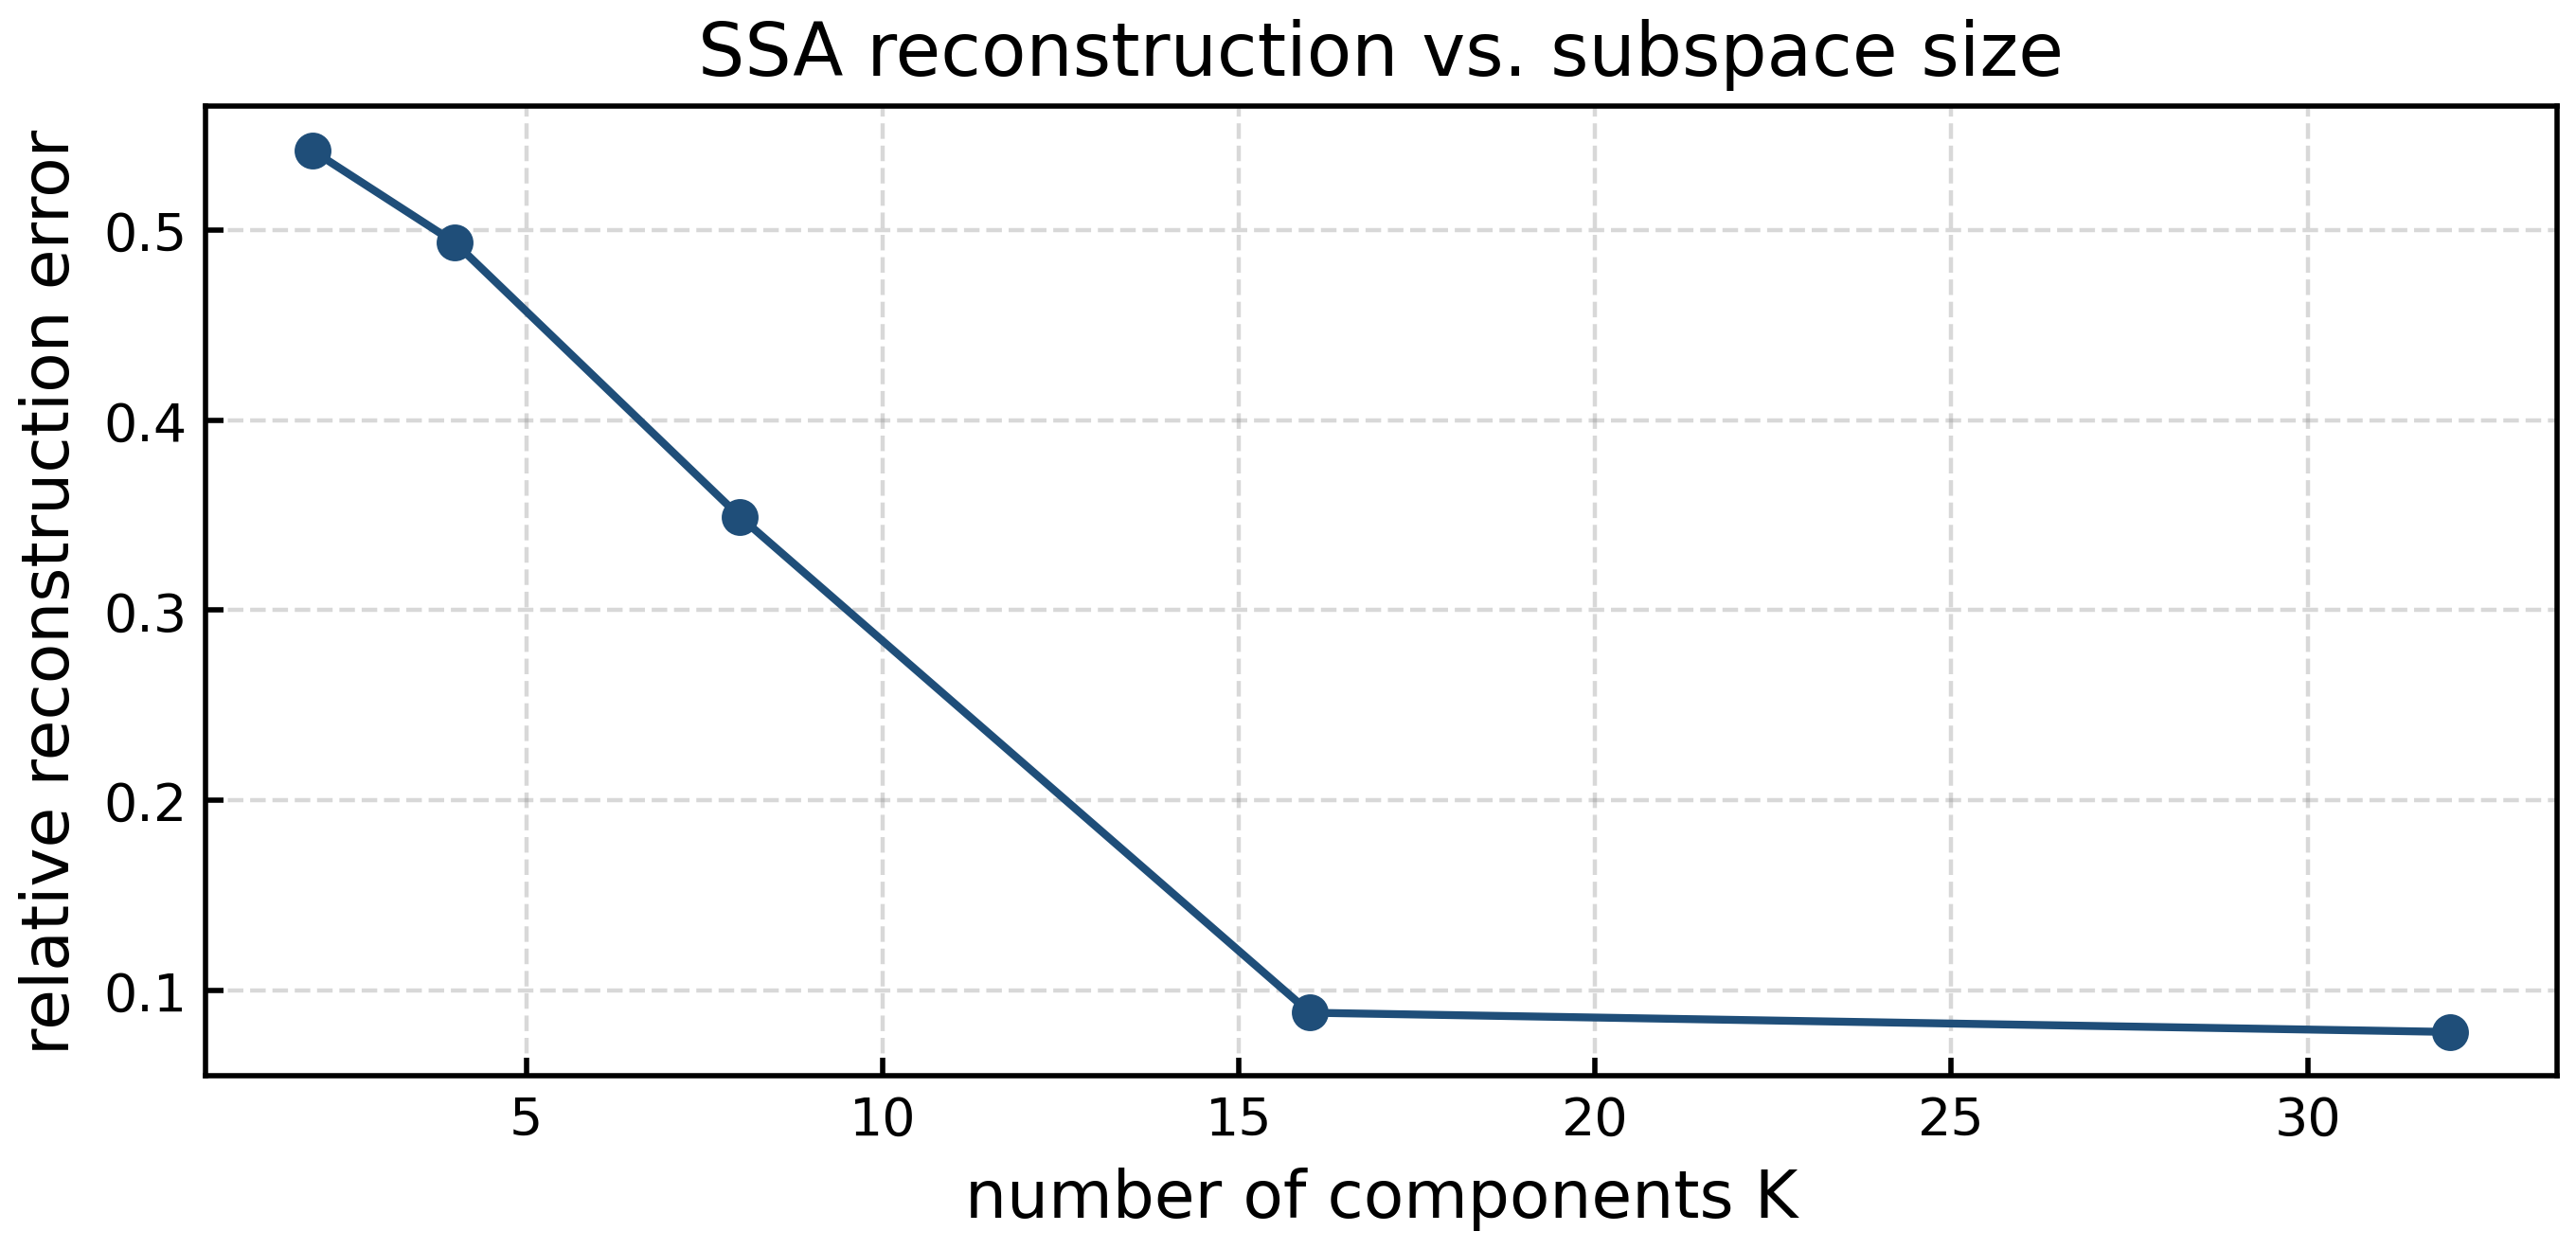

K= 2  rel_err=0.5420
K= 4  rel_err=0.4935
K= 8  rel_err=0.3493
K=16  rel_err=0.0882
K=32  rel_err=0.0781


In [8]:
Ks = [2, 4, 8, 16, 32]
errors = []
for K in Ks:
    recon = SSA(K=K, mode="traj").fit_transform(emd_signal).sum(axis=0)
    errors.append(np.linalg.norm(recon - emd_signal) / np.linalg.norm(emd_signal))

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.plot(Ks, errors, marker="o", color="#1f4e79")
ax.set_xlabel("number of components K")
ax.set_ylabel("relative reconstruction error")
ax.set_title("SSA reconstruction vs. subspace size")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

for K, e in zip(Ks, errors):
    print(f"K={K:2d}  rel_err={e:.4f}")

## 5. Trend + oscillation + noise

A final example closer to real analysis tasks: separate a linear trend and a
harmonic from additive Gaussian noise by retaining only the leading SSA
components.

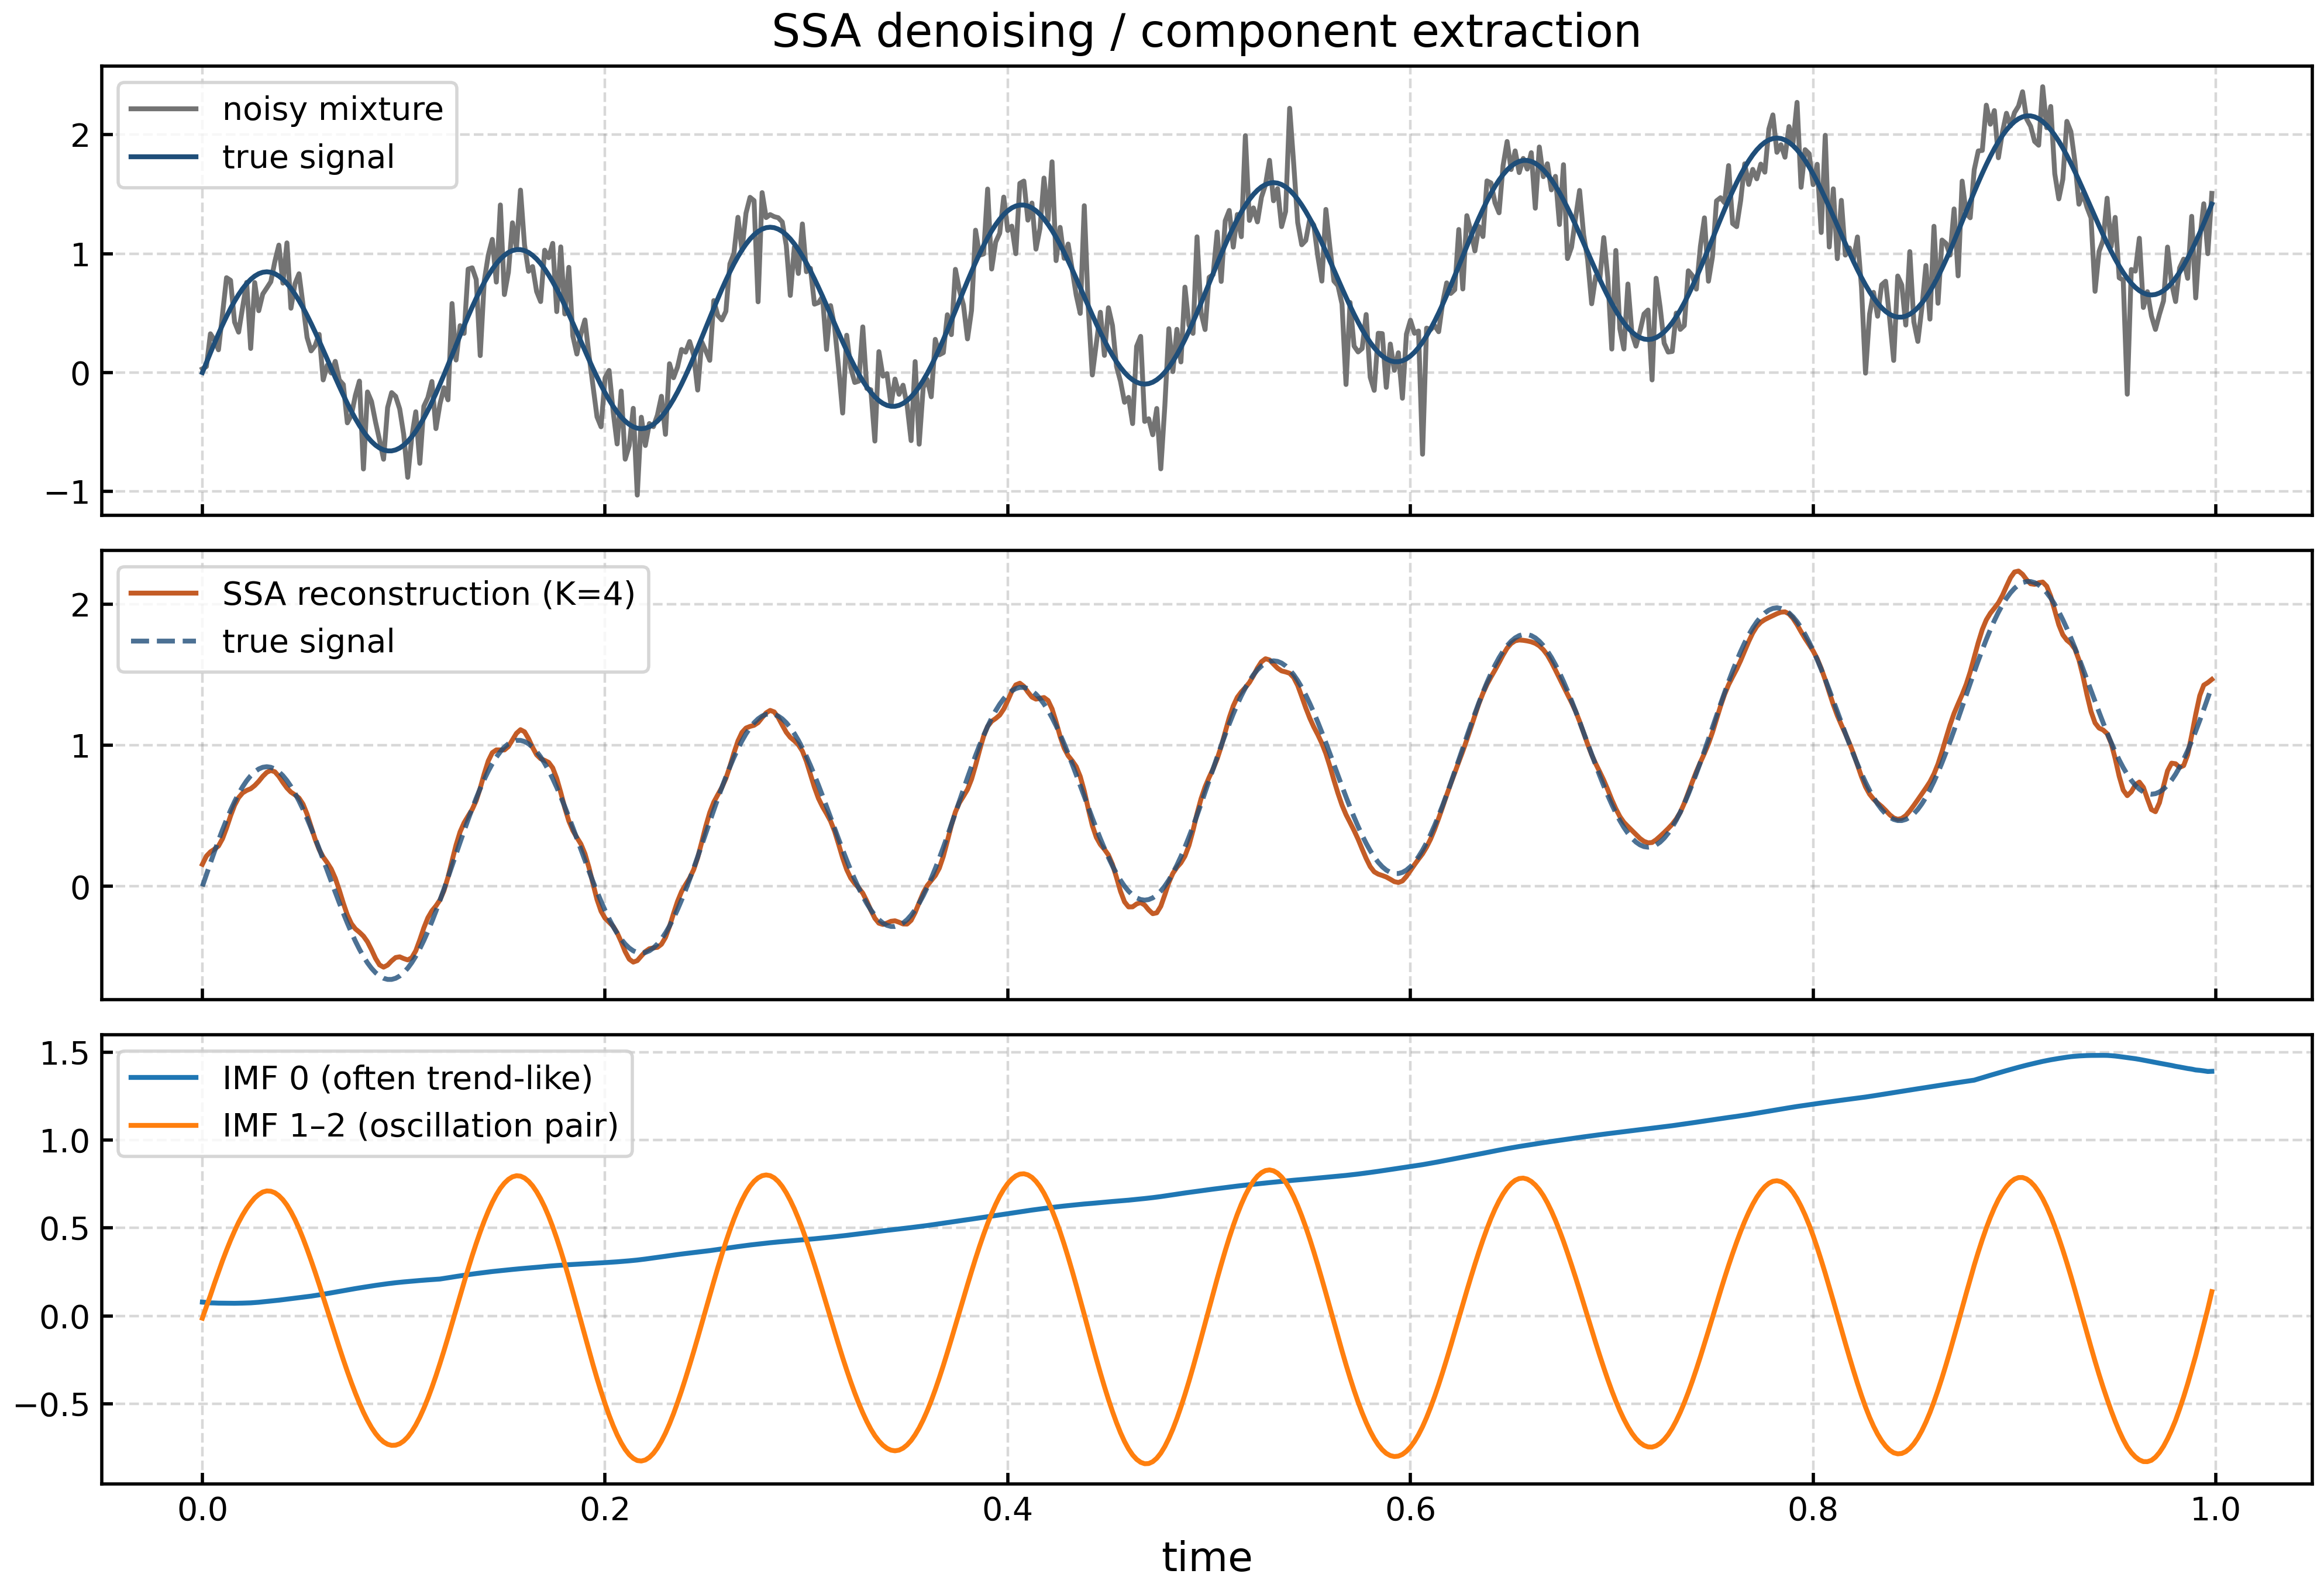

input  SNR ≈ 12.0 dB
output SNR ≈ 24.8 dB


In [9]:
rng = np.random.default_rng(0)
N = 500
t = np.linspace(0, 1, N, endpoint=False)

trend = 1.5 * t
osc = 0.8 * np.sin(2 * np.pi * 8 * t)
noise = 0.25 * rng.standard_normal(N)
mixed = trend + osc + noise

# Keep a small subspace: trend (~1–2) + harmonic pair (~2) ≈ 4 components
ssa_denoise = SSA(K=4, mode="traj", lags=60)
IMFs_dn = ssa_denoise.fit_transform(mixed)
clean = IMFs_dn.sum(axis=0)

fig, axes = plt.subplots(3, 1, figsize=(10, 7), sharex=True)
axes[0].plot(t, mixed, color="0.45", label="noisy mixture")
axes[0].plot(t, trend + osc, color="#1f4e79", lw=1.5, label="true signal")
axes[0].legend(loc="upper left")
axes[0].set_title("SSA denoising / component extraction")

axes[1].plot(t, clean, color="#c45c26", label="SSA reconstruction (K=4)")
axes[1].plot(t, trend + osc, color="#1f4e79", ls="--", alpha=0.8, label="true signal")
axes[1].legend(loc="upper left")

axes[2].plot(t, IMFs_dn[0], label="IMF 0 (often trend-like)")
axes[2].plot(t, IMFs_dn[1:3].sum(0), label="IMF 1–2 (oscillation pair)")
axes[2].legend(loc="upper left")
axes[2].set_xlabel("time")

for ax in axes:
    ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

snr_in = np.linalg.norm(trend + osc) / np.linalg.norm(noise)
snr_out = np.linalg.norm(trend + osc) / np.linalg.norm(clean - (trend + osc))
print(f"input  SNR ≈ {20*np.log10(snr_in):.1f} dB")
print(f"output SNR ≈ {20*np.log10(snr_out):.1f} dB")

## 6. API summary

| Item | Description |
| --- | --- |
| `SSA(K, mode, lags, averaging, extra_size)` | constructor |
| `K` | number of leading singular components to keep |
| `mode` | lag-matrix type; use `"traj"` for classical SSA |
| `lags` | window length $L$ (default $N//2$) |
| `fit_transform(signal)` | return array of shape `(K, N)` |
| `ssa(signal)` | same as `fit_transform` |

```python
from pysdkit import SSA

ssa = SSA(K=4, mode="traj", lags=80)
IMFs = ssa.fit_transform(signal)   # shape: (4, N)
```

## 7. Takeaways

- SSA embeds a series into a Hankel trajectory matrix and splits it with an SVD.
- Leading singular components capture trend and coherent oscillations; small
  singular values are typically noise.
- A pure sinusoid usually occupies **two** components — choose `K` accordingly.
- `PySDKit` wraps the full pipeline behind the unified `fit_transform` interface.
